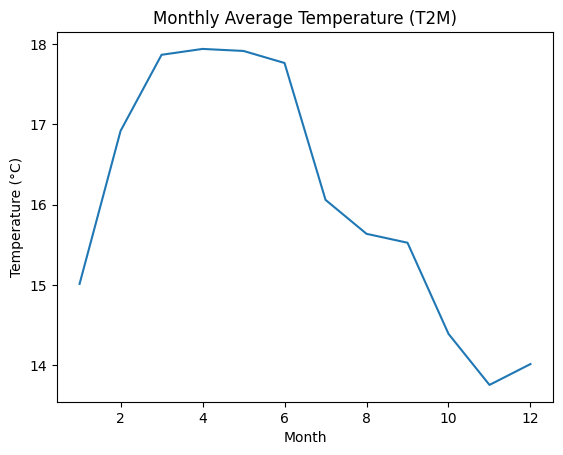

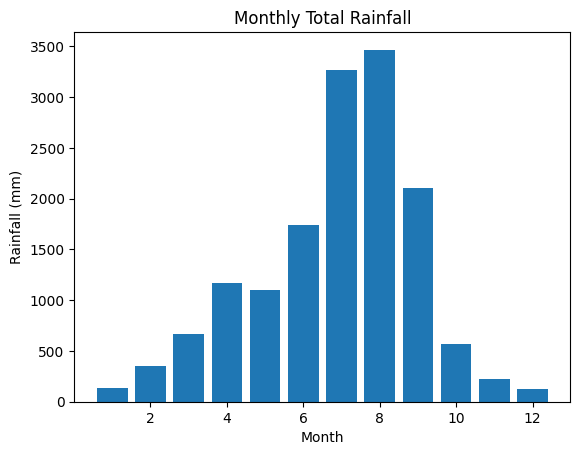

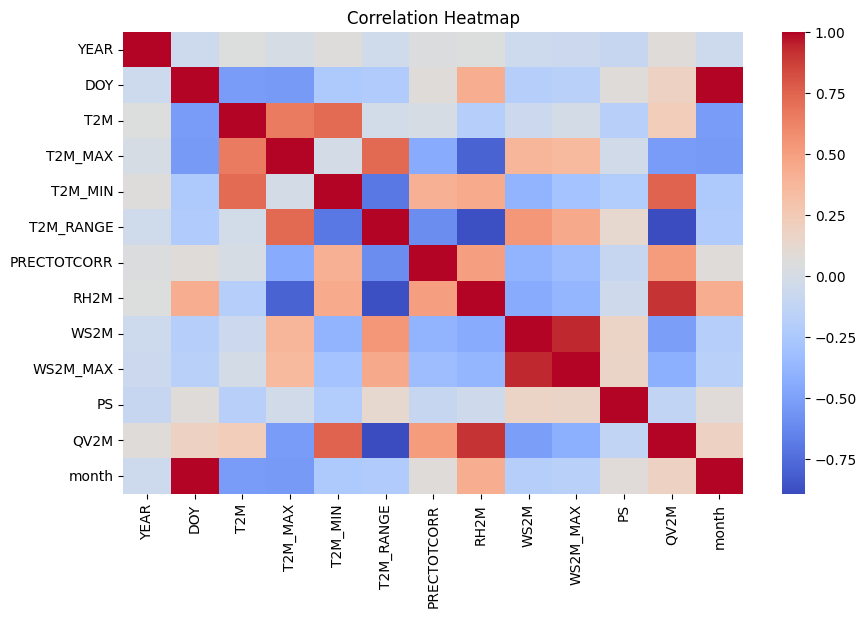

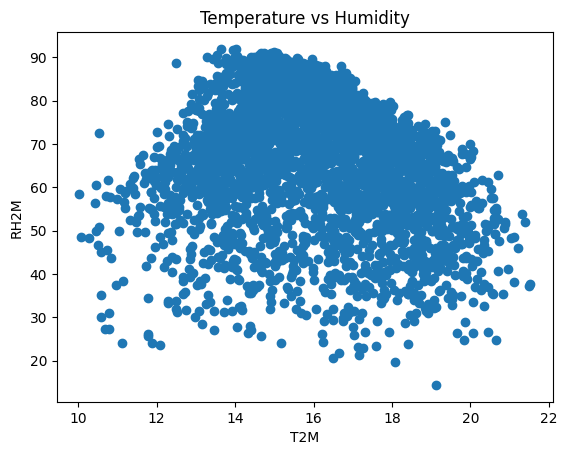

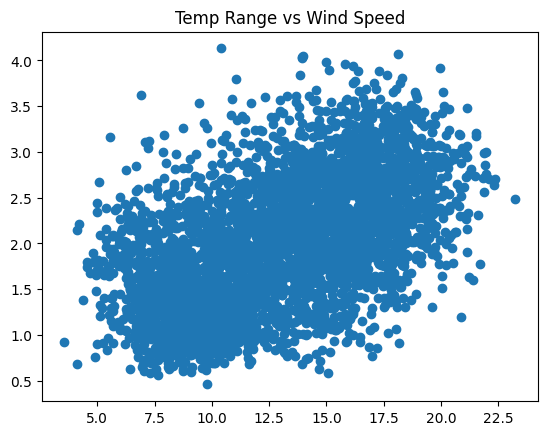

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/ethiopia.csv")
df.head()
df["Country"] = "Ethiopia"
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["month"] = df["date"].dt.month


df["month"] = df["date"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df.isna().sum()
(df.isna().sum() / len(df)) * 100
df.describe()
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy="omit"))

outliers = (z_scores > 3).sum()
outliers
df = df.ffill()
df.to_csv("../data/ethiopia.csv", index=False)
monthly_temp = df.groupby("month")["T2M"].mean()

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()
monthly_rain = df.groupby("month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Total Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temperature vs Humidity")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.title("Temp Range vs Wind Speed")
plt.show()